In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
from typing import Dict, Tuple, List
import time

--- 探索ミッション開始 ---


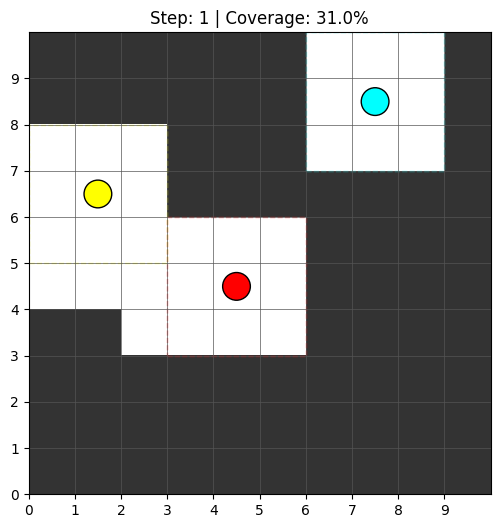

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

中断しました


In [2]:

# 環境設定
GRID_SIZE = 15          # マップの広さ
NUM_AGENTS = 3          # ドローンの数
SENSOR_RANGE = 1        # センサーの範囲（1なら自身の周囲1マス=3x3が見える）
MAX_STEPS = 100         # 1エピソードの最大ステップ数

class MultiSensorSearchEnv:
    def __init__(self, size: int = GRID_SIZE, num_agents: int = NUM_AGENTS):
        self.size = size
        self.num_agents = num_agents
        self.action_space = 5  # 0:待機, 1:上, 2:下, 3:左, 4:右

        # 探索状態マップ (0: 未探索, 1: 探索済み)
        self.explored_map = np.zeros((self.size, self.size), dtype=int)

        # Matplotlib用の図の保持
        self.fig = None
        self.ax = None

        self.reset()

    def reset(self) -> Dict[int, np.ndarray]:
        """環境を初期化します。"""
        # マップを全て「未探索(0)」にリセット
        self.explored_map = np.zeros((self.size, self.size), dtype=int)
        self.current_step = 0

        # エージェントの位置をランダムに初期化（スタート時は重なっても良いとする）
        self.agent_positions = {
            i: (random.randint(0, self.size - 1), random.randint(0, self.size - 1))
            for i in range(self.num_agents)
        }

        # 初期位置での探索を反映
        self._update_exploration()

        return self._get_obs()

    def _get_obs(self) -> Dict[int, Dict]:
        """
        観測を返します。
        簡単のため、全エージェントが「自分の位置」と「グローバルな探索マップ」を共有しているとします。
        (分散知識問題にする場合は、ここを個別のローカルマップに変更します)
        """
        obs = {}
        for i in range(self.num_agents):
            obs[i] = {
                "position": self.agent_positions[i],
                "map": self.explored_map.copy() # 共有された探索済みマップ
            }
        return obs

    def _update_exploration(self) -> int:
        """現在のエージェントの位置に基づいて探索済みエリアを更新し、新規探索セル数を返します。"""
        newly_explored_count = 0

        for pos in self.agent_positions.values():
            x, y = pos
            # センサー範囲 (正方形) の計算
            x_min = max(0, x - SENSOR_RANGE)
            x_max = min(self.size, x + SENSOR_RANGE + 1)
            y_min = max(0, y - SENSOR_RANGE)
            y_max = min(self.size, y + SENSOR_RANGE + 1)

            # 範囲内の未探索セルをカウント
            current_area = self.explored_map[y_min:y_max, x_min:x_max]
            newly_explored_count += np.sum(current_area == 0)

            # マップを更新 (1にする)
            self.explored_map[y_min:y_max, x_min:x_max] = 1

        return newly_explored_count

    def step(self, actions: Dict[int, int]) -> Tuple[Dict, Dict, bool, Dict]:
        """行動を実行し、状態を進めます。"""
        self.current_step += 1
        rewards = {i: -0.1 for i in range(self.num_agents)} # タイムペナルティ

        # 1. 移動の実行
        for i, action in actions.items():
            cx, cy = self.agent_positions[i]
            nx, ny = cx, cy

            if action == 1: ny += 1  # 上
            elif action == 2: ny -= 1  # 下
            elif action == 3: nx -= 1  # 左
            elif action == 4: nx += 1  # 右

            # マップ外に出ないようにクリップ
            nx = np.clip(nx, 0, self.size - 1)
            ny = np.clip(ny, 0, self.size - 1)

            self.agent_positions[i] = (nx, ny)

        # 2. 探索エリアの更新と報酬計算
        # チーム全員で協力して発見した「新しいマス」の数に応じて報酬を与える (協調報酬)
        new_cells = self._update_exploration()

        # 協調報酬: 新しく発見したマス1つにつき +1.0 をチーム全員（または発見者）に分配
        # ここではシンプルに全員に同じ報酬を与える「完全協力ゲーム」とします
        team_reward = new_cells * 1.0

        for i in range(self.num_agents):
            rewards[i] += team_reward

        # 3. 終了判定
        # 全てのマスが探索済み (探索率 100%) になったら終了
        total_cells = self.size * self.size
        explored_cells = np.sum(self.explored_map)
        coverage_ratio = explored_cells / total_cells

        done = coverage_ratio >= 1.0 or self.current_step >= MAX_STEPS

        if coverage_ratio >= 1.0:
            # コンプリートボーナス
            for i in range(self.num_agents):
                rewards[i] += 20.0

        info = {
            "coverage": coverage_ratio,
            "new_cells": new_cells
        }

        return self._get_obs(), rewards, done, info

    # --- 可視化メソッド ---
    def render(self, mode='graphic', sleep_time=0.1):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(6, 6))

        self.ax.clear()

        # グリッドの描画設定
        # 未探索(0) = 黒/グレー, 探索済み(1) = 白/明るい色
        cmap = colors.ListedColormap(['#333333', '#ffffff'])
        bounds = [0, 0.5, 1]
        norm = colors.BoundaryNorm(bounds, cmap.N)

        # マップの表示 (origin='lower'で左下を(0,0)にする)
        self.ax.imshow(self.explored_map, cmap=cmap, norm=norm, origin='lower', extent=[0, self.size, 0, self.size])

        # グリッド線
        self.ax.set_xticks(np.arange(0, self.size, 1))
        self.ax.set_yticks(np.arange(0, self.size, 1))
        self.ax.grid(which='both', color='#555555', linestyle='-', linewidth=0.5)

        # 進捗率の表示
        coverage = (np.sum(self.explored_map) / (self.size**2)) * 100
        self.ax.set_title(f"Step: {self.current_step} | Coverage: {coverage:.1f}%")

        # エージェントの描画
        agent_colors = ['red', 'cyan', 'yellow', 'lime']
        for i, pos in self.agent_positions.items():
            x, y = pos

            # エージェント本体
            circle = patches.Circle((x + 0.5, y + 0.5), 0.3, facecolor=agent_colors[i % len(agent_colors)], edgecolor='black', zorder=10)
            self.ax.add_patch(circle)

            # センサー範囲の枠線（オプション）
            rect_size = SENSOR_RANGE * 2 + 1
            rect = patches.Rectangle((x - SENSOR_RANGE, y - SENSOR_RANGE), rect_size, rect_size,
                                     linewidth=1, edgecolor=agent_colors[i % len(agent_colors)], facecolor='none', linestyle='--', alpha=0.5)
            self.ax.add_patch(rect)

        plt.draw()
        plt.pause(sleep_time)

# --- 実行例 ---
if __name__ == '__main__':
    # ランダムウォークによるシミュレーション
    env = MultiSensorSearchEnv(size=10, num_agents=3) # 10x10マップ, 3機
    obs = env.reset()

    print("--- 探索ミッション開始 ---")

    try:
        while True:
            # ランダムアクション
            actions = {i: random.randint(0, 4) for i in range(env.num_agents)}

            obs, rewards, done, info = env.step(actions)

            env.render(sleep_time=0.2)

            if done:
                print(f"ミッション終了！ 最終カバレッジ: {info['coverage']*100:.1f}%")
                plt.pause(2.0)
                break

    except KeyboardInterrupt:
        print("中断しました")

    plt.ioff()
    plt.show()

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt


In [4]:

# --- ハイパーパラメータ ---
BATCH_SIZE = 64
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 2000
TARGET_UPDATE = 100
LR = 0.001
MEMORY_SIZE = 10000
HIDDEN_SIZE = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. ニューラルネットワークの定義 (DQN) ---
class DuelingDQN(nn.Module):
    def __init__(self, h, w, outputs):
        super(DuelingDQN, self).__init__()
        # 入力: 2チャンネル (マップ + 自分の位置), 高さh, 幅w

        # 畳み込み層: 空間的な特徴（未探索エリアの塊など）を抽出
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)

        # 畳み込み後のサイズ計算
        def conv2d_size_out(size, kernel_size=3, stride=1, padding=1):
            return (size + 2 * padding - (kernel_size - 1) - 1) // stride + 1

        convw = conv2d_size_out(conv2d_size_out(w))
        convh = conv2d_size_out(conv2d_size_out(h))
        linear_input_size = convw * convh * 32

        # 全結合層
        self.fc1 = nn.Linear(linear_input_size, 128)
        self.head = nn.Linear(128, outputs)

    def forward(self, x):
        # x shape: (batch, 2, h, w)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1) # Flatten
        x = F.relu(self.fc1(x))
        return self.head(x)

# --- 2. 経験再生バッファ (Replay Memory) ---
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward, done):
        # PyTorch Tensorとして保存するために変換などの処理を挟んでも良い
        self.memory.append((state, action, next_state, reward, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# --- 3. エージェントと学習プロセス ---
class SharedAgent:
    def __init__(self, grid_size, action_space):
        self.grid_size = grid_size
        self.action_space = action_space

        # ネットワークの構築
        self.policy_net = DuelingDQN(grid_size, grid_size, action_space).to(device)
        self.target_net = DuelingDQN(grid_size, grid_size, action_space).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory = ReplayMemory(MEMORY_SIZE)
        self.steps_done = 0

    def preprocess_state(self, obs, agent_id):
        """
        環境からの観測をニューラルネットに入力できるTensor形式(2, H, W)に変換
        Ch0: 共有探索マップ
        Ch1: エージェント自身の位置 (One-hot)
        """
        # マップ情報の取得
        explored_map = obs[agent_id]["map"] # shape (H, W)

        # エージェント位置情報の作成
        agent_pos = obs[agent_id]["position"] # (x, y)
        pos_map = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)

        # numpyは(row, col) = (y, x) なので注意
        # 範囲外チェックは環境側で行われている前提だが念のため
        px, py = agent_pos
        if 0 <= py < self.grid_size and 0 <= px < self.grid_size:
            pos_map[py, px] = 1.0

        # チャンネル結合 (2, H, W)
        state = np.stack([explored_map, pos_map], axis=0)
        return torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0) # バッチ次元追加 (1, 2, H, W)

    def select_action(self, state):
        sample = random.random()
        eps_threshold = EPS_END + (EPS_START - EPS_END) * \
            np.exp(-1. * self.steps_done / EPS_DECAY)
        self.steps_done += 1

        if sample > eps_threshold:
            with torch.no_grad():
                # 最大のQ値を持つ行動を選択
                return self.policy_net(state).max(1)[1].view(1, 1)
        else:
            # ランダム行動
            return torch.tensor([[random.randrange(self.action_space)]], device=device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < BATCH_SIZE:
            return

        transitions = self.memory.sample(BATCH_SIZE)
        # バッチデータの整理
        batch_state, batch_action, batch_next_state, batch_reward, batch_done = zip(*transitions)

        state_batch = torch.cat(batch_state)
        action_batch = torch.cat(batch_action)
        reward_batch = torch.cat(batch_reward)
        next_state_batch = torch.cat(batch_next_state)
        done_batch = torch.cat(batch_done)

        # Q(s, a) の計算
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        # V(s') = max_a Q(s', a) の計算 (Target Network使用)
        next_state_values = self.target_net(next_state_batch).max(1)[0].detach()
        # 終了状態の場合は 0
        expected_state_action_values = (next_state_values * GAMMA * (1 - done_batch)) + reward_batch

        # Loss計算 (Huber Loss or MSE)
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        # 最適化
        self.optimizer.zero_grad()
        loss.backward()

        # 勾配クリッピング (安定化のため)
        for param in self.policy_net.parameters():
            param.grad.data.clamp_(-1, 1)

        self.optimizer.step()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())


# --- メイン学習ループ ---
def train_multi_agent_search(save_path: str = "trained_search_agent.pth"):
    # 環境の生成 (前の回答のコードが必要です)
    # env = MultiSensorSearchEnv(size=10, num_agents=3) # size=10, num_agents=3 は環境定義から取得

    # 環境の定義がないため、仮の値を設定
    try:
        env = MultiSensorSearchEnv(size=10, num_agents=3)
    except NameError:
        print("警告: MultiSensorSearchEnvクラスが定義されていません。環境の初期化をスキップします。")
        return None, None, None

    # 共有エージェント脳の生成
    agent_brain = SharedAgent(grid_size=env.size, action_space=env.action_space)

    num_episodes = 500
    rewards_history = []
    coverage_history = []

    print("--- 学習開始 (DQN) ---")

    for i_episode in range(num_episodes):
        obs = env.reset()

        # エージェントごとの初期状態Tensorを作成
        state = {i: agent_brain.preprocess_state(obs, i) for i in range(env.num_agents)}

        total_reward = 0

        for t in range(100): # Max steps
            actions = {}

            # 1. 全エージェントの行動決定
            for i in range(env.num_agents):
                action = agent_brain.select_action(state[i])
                actions[i] = action.item()

            # 2. 環境実行
            next_obs, rewards, done, info = env.step(actions)

            # 3. 経験の保存と状態更新
            for i in range(env.num_agents):
                # rewards[i] や done は前の回答のコードでは dict の値なので、ここではその dict の値を適切に取得しているものとします。
                reward_tensor = torch.tensor([rewards[i]], device=device)
                next_state_tensor = agent_brain.preprocess_state(next_obs, i)
                done_tensor = torch.tensor([float(done)], device=device)

                # メモリに追加
                agent_brain.memory.push(state[i],
                                       torch.tensor([[actions[i]]], device=device, dtype=torch.long), # action tensorの型を修正
                                       next_state_tensor,
                                       reward_tensor,
                                       done_tensor)

                # 状態更新
                state[i] = next_state_tensor
                total_reward += rewards[i]

            # 4. モデルの最適化 (1ステップごとに学習)
            agent_brain.optimize_model()

            if done:
                break

        # ターゲットネットワークの定期更新
        if i_episode % TARGET_UPDATE == 0:
            agent_brain.update_target_network()

        rewards_history.append(total_reward)
        coverage_history.append(info['coverage'])

        # ログ出力
        if (i_episode + 1) % 10 == 0:
            epsilon_val = EPS_END + (EPS_START - EPS_END) * np.exp(-1. * agent_brain.steps_done / EPS_DECAY)
            print(f"Episode {i_episode+1}/{num_episodes} | Total Reward: {total_reward:.2f} | Coverage: {info['coverage']*100:.1f}% | Epsilon: {epsilon_val:.2f}")


    # --- モデルの保存処理 ---

    # 保存するデータは、モデルの重み（state_dict）と学習履歴を推奨
    save_data = {
        'episode': num_episodes,
        'model_state_dict': agent_brain.policy_net.state_dict(),
        'optimizer_state_dict': agent_brain.optimizer.state_dict(),
        'rewards_history': rewards_history,
        'coverage_history': coverage_history,
        'hyperparameters': { # 必要に応じてハイパーパラメータも保存
            'GRID_SIZE': env.size,
            'NUM_AGENTS': env.num_agents,
            # ... 他のハイパーパラメータもここに追加
        }
    }

    torch.save(save_data, save_path)
    print(f"\n✅ 学習済みモデルと履歴を {save_path} に保存しました。")

    return agent_brain, rewards_history, coverage_history

In [ ]:
# 学習の実行
trained_brain, rewards, coverages = train_multi_agent_search()

# 学習曲線の表示
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rewards)
plt.title("Total Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.subplot(1, 2, 2)
plt.plot(coverages)
plt.title("Map Coverage Ratio")
plt.xlabel("Episode")
plt.ylabel("Coverage (0.0 - 1.0)")
plt.show()

# --- 学習済みモデルでのテスト実行 ---
print("\n--- テスト実行 (可視化) ---")
env = MultiSensorSearchEnv(size=10, num_agents=3)
obs = env.reset()
state = {i: trained_brain.preprocess_state(obs, i) for i in range(env.num_agents)}

# 探索率(ε)を0にして、学習した知識のみで動かす
trained_brain.policy_net.eval()

for t in range(100):
    actions = {}
    for i in range(env.num_agents):
        with torch.no_grad():
            # ε-greedyを使わず、最大のQ値を持つ行動を選択
            action = trained_brain.policy_net(state[i]).max(1)[1].item()
        actions[i] = action

    next_obs, rewards, done, info = env.step(actions)

    # 可視化
    env.render(sleep_time=0.2)

    state = {i: trained_brain.preprocess_state(next_obs, i) for i in range(env.num_agents)}

    if done:
        print(f"テスト完了！ 最終カバレッジ: {info['coverage']*100:.1f}%")
        plt.pause(2.0)
        break

plt.ioff()
plt.show()

--- 学習開始 (DQN) ---
